# Week 7-1 · Tutorial — Doubt-Solving on Python after PBQ-02
**Module:** Python Basics & Its Quant Ecosystem (tutorial) · A practical pandas clinic.

This session answers the recurring "how do I actually…?" questions about pandas: **setting display options**,
**silencing warnings**, **reading market-data CSVs cleanly**, fixing **trailing-space column names**, the
**index evolution** (range → object → datetime), reading dates correctly in one shot, **extracting data with
`.loc` / `.iloc`**, and finally **plotting candlesticks**. We use the real `TCS.NS.csv` daily file.

> The lecture demonstrates candlesticks with **Plotly**; Plotly isn't installed here, so the last section
> draws the identical chart with matplotlib — the mechanics (OHLC → boxes & wicks) are the same.

## 1. Imports + silence warnings
Warnings (e.g. deprecations) are not errors; we filter them so they don't clutter the screen.

In [1]:
import warnings
warnings.filterwarnings("ignore")     # this is itself a *setting* on the current kernel
import numpy as np
import pandas as pd
print("pandas", pd.__version__)

pandas 3.0.3


## 2. Set / reset display options
Market prices in scientific notation (`1e-05`) are unreadable. `pd.set_option('display.float_format', …)`
fixes the format; `pd.reset_option(…)` restores the default.

In [2]:
tiny = [1e-5, 2e-6, 3.4e-5, 5e-7]
s = pd.Series(tiny)
print("default (scientific):")
print(s.to_string())

pd.set_option("display.float_format", lambda x: f"{x:.8f}")
print("\nfloat_format 8 decimals:")
print(s.to_string())

pd.reset_option("display.float_format")
print("\nafter reset (scientific again):", s.iloc[0])

default (scientific):
0    1.000000e-05
1    2.000000e-06
2    3.400000e-05
3    5.000000e-07

float_format 8 decimals:
0   0.00001000
1   0.00000200
2   0.00003400
3   0.00000050

after reset (scientific again): 1e-05


### display.max_rows
By default pandas truncates long frames with `…`. You *can* show everything — but it slows the kernel, so reset it after.

In [3]:
demo = pd.DataFrame({"x": range(100)})
pd.set_option("display.max_rows", 100)
print("max_rows now:", pd.get_option("display.max_rows"))
pd.reset_option("display.max_rows")
print("after reset:", pd.get_option("display.max_rows"))

max_rows now: 100
after reset: 60


## 3. Read a market-data CSV
`pd.read_csv` is intuitively named. First we read it *plainly* to expose two classic beginner traps.

In [4]:
raw = pd.read_csv("TCS.NS.csv")
print("shape:", raw.shape)
print("columns:", list(raw.columns))
print(raw.head(3))

shape: (1233, 8)
columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Direction']
         Date         Open         High          Low        Close  \
0  18/11/2015  1194.449951  1194.449951  1173.000000  1175.719971   
1  19/11/2015  1182.680054  1190.800049  1176.000000  1181.280029   
2  20/11/2015  1183.250000  1211.780029  1180.969971  1199.180054   

     Adj Close     Volume Direction  
0  1038.072876  1520352.0       NaN  
1  1042.982178  1866906.0        UP  
2  1058.786377  2012126.0        UP  


### Trap 1 — trailing spaces in column names
Real exchange exports often have names like `'Value '` with a hidden space, so `df['Value']` raises a
KeyError. `str.strip()` cleans every name.

In [5]:
# simulate the messy export the instructor showed
messy = raw.copy()
messy.columns = [c + " " for c in raw.columns]      # add a trailing space to each
print("messy:", list(messy.columns))
try:
    messy["Close"]
except KeyError as e:
    print("lookup fails ->", e)
messy.columns = messy.columns.str.strip()           # the fix
print("stripped:", list(messy.columns))
print("now Close works, first value:", round(messy["Close"].iloc[0], 2))

messy: ['Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Adj Close ', 'Volume ', 'Direction ']
lookup fails -> 'Close'
stripped: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Direction']
now Close works, first value: 1175.72


## 4. Series vs DataFrame
A DataFrame is a collection of columns; **each single column is a Series**.

In [6]:
print("type df:", type(raw).__name__)
print("type df['Close']:", type(raw["Close"]).__name__)       # Series
print("type df[['Close']]:", type(raw[["Close"]]).__name__)   # DataFrame

type df: DataFrame
type df['Close']: Series
type df[['Close']]: DataFrame


## 5. `.info()` and the index evolution
The default index is a **RangeIndex** (0,1,2…). For time series we want the **Date** to be the index, and we
want it understood as a *date*, not a string. The instructor walks it through three stages.

In [7]:
print("--- df.info() ---")
raw.info()
print("\nindex now:", raw.index)

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1233 non-null   str    
 1   Open       1232 non-null   float64
 2   High       1232 non-null   float64
 3   Low        1232 non-null   float64
 4   Close      1232 non-null   float64
 5   Adj Close  1232 non-null   float64
 6   Volume     1232 non-null   float64
 7   Direction  1232 non-null   str    
dtypes: float64(6), str(2)
memory usage: 77.2 KB

index now: RangeIndex(start=0, stop=1233, step=1)


### Stage A → set Date as index (still a plain object/string index)

In [8]:
stepA = raw.set_index("Date")          # NOT in place unless we reassign / inplace=True
print("index dtype:", stepA.index.dtype, "| type:", type(stepA.index).__name__)
print("one label:", stepA.index[0], "->", type(stepA.index[0]).__name__)   # str

index dtype: str | type: Index
one label: 18/11/2015 -> str


### Stage B → convert to a real DatetimeIndex with pd.to_datetime (dayfirst, dd/mm/yyyy)

In [9]:
stepB = stepA.copy()
stepB.index = pd.to_datetime(stepB.index, dayfirst=True)
print("index type now:", type(stepB.index).__name__)      # DatetimeIndex
print("one label:", stepB.index[0])

index type now: DatetimeIndex
one label: 2015-11-18 00:00:00


### The clean one-shot way
Do it all in `read_csv`: `index_col=0` (or `'Date'`) + `parse_dates=True` + `dayfirst=True`. No duplicate
Date column, DatetimeIndex straight away.

In [10]:
df = pd.read_csv("TCS.NS.csv", index_col=0, parse_dates=True, dayfirst=True)
print("index type:", type(df.index).__name__)
print("columns (no separate Date):", list(df.columns))
print("is monotonic (sorted) in time:", df.index.is_monotonic_increasing)

index type: DatetimeIndex
columns (no separate Date): ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Direction']
is monotonic (sorted) in time: True


## 6. Extract data: `.loc` (by label) vs `.iloc` (by position)
First the list-slicing recap: `lst[0:2]` includes 0 and 1, excludes 2.

In [11]:
stock_list = ["META", "AAPL", "MSFT", "GOOG", "AMZN"]
print("first:", stock_list[0], " last:", stock_list[-1])
print("slice [0:2]:", stock_list[0:2])     # 2 excluded
print("slice [2:]:", stock_list[2:])

first: META  last: AMZN
slice [0:2]: ['META', 'AAPL']
slice [2:]: ['MSFT', 'GOOG', 'AMZN']


### .loc — rows & columns by name

In [12]:
print("all rows, Close column (head):")
print(df.loc[:, "Close"].head(3))
print("\nall rows, Open+Close (head):")
print(df.loc[:, ["Open", "Close"]].head(3))
one_day = df.index[10]
print(f"\nall columns for {one_day.date()}:")
print(df.loc[one_day])

all rows, Close column (head):
Date
2015-11-18    1175.719971
2015-11-19    1181.280029
2015-11-20    1199.180054
Name: Close, dtype: float64

all rows, Open+Close (head):
                   Open        Close
Date                                
2015-11-18  1194.449951  1175.719971
2015-11-19  1182.680054  1181.280029
2015-11-20  1183.250000  1199.180054

all columns for 2015-12-03:
Open              1180.0
High              1186.5
Low               1173.5
Close        1175.380005
Adj Close    1037.772705
Volume         2283358.0
Direction           DOWN
Name: 2015-12-03 00:00:00, dtype: object


### .iloc — rows & columns by position; head / tail

In [13]:
print("rows 5..7, first 4 cols:")
print(df.iloc[5:8, 0:4])
print("\nlast 5 rows (Close):")
print(df["Close"].tail())

rows 5..7, first 4 cols:
                   Open         High          Low        Close
Date                                                          
2015-11-26  1188.949951  1191.199951  1168.930054  1172.780029
2015-11-27  1174.000000  1179.719971  1166.250000  1176.680054
2015-11-30  1182.500000  1195.619995  1175.069946  1186.780029

last 5 rows (Close):
Date
2020-11-10    2649.600098
2020-11-11    2687.800049
2020-11-12    2671.050049
2020-11-13    2656.850098
2020-11-17    2666.050049
Name: Close, dtype: float64


## 7. Plotting candlesticks
Yes — Python plots candlesticks. The lecture uses **Plotly** (`go.Candlestick`). Plotly isn't installed
here, so we build the same picture with matplotlib for the last 30 trading days: a box from **open→close**
(green up, red down) with a high–low **wick**.

In [14]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

recent = df.tail(30)
fig, ax = plt.subplots(figsize=(8, 3.5))
for i, (dt, row) in enumerate(recent.iterrows()):
    up = row["Close"] >= row["Open"]
    color = "#16a34a" if up else "#dc2626"
    ax.plot([i, i], [row["Low"], row["High"]], color=color, lw=0.8)            # wick
    lo, hi = sorted([row["Open"], row["Close"]])
    ax.add_patch(plt.Rectangle((i-0.3, lo), 0.6, max(hi-lo, 0.1), color=color))  # body
ax.set_title("TCS.NS — last 30 days (candlesticks)")
ax.set_ylabel("Price (Rs)")
ax.set_xticks(range(0, 30, 5))
ax.set_xticklabels([recent.index[j].strftime("%d-%b") for j in range(0, 30, 5)], fontsize=8)
fig.tight_layout()
fig.savefig("candles_preview.png", dpi=110)
print("candlestick figure built for", recent.index[0].date(), "to", recent.index[-1].date())

candlestick figure built for 2020-10-06 to 2020-11-17


## Key takeaways
- **Warnings ≠ errors.** `warnings.filterwarnings('ignore')` is a kernel setting that hides the clutter; code still runs.
- **Display options:** `pd.set_option('display.float_format', …)` makes prices readable; `display.max_rows` shows everything (then `reset_option` to keep the kernel fast).
- **`read_csv`** is the entry point; clean trailing-space column names with `df.columns.str.strip()`.
- A **DataFrame** is a set of columns; each column is a **Series**.
- **Index evolution:** RangeIndex → set_index(Date) (object) → pd.to_datetime (DatetimeIndex). The one-shot way is `read_csv(index_col=0, parse_dates=True, dayfirst=True)`.
- **Extract:** `.loc` by label (`df.loc[:, ['Open','Close']]`), `.iloc` by position (`df.iloc[5:8, 0:4]`); slices exclude the stop. Handle nulls *after* EDA, never blindly with `dropna` on download.
- Python **plots candlesticks** (Plotly's `go.Candlestick`, or matplotlib): body = open→close, wick = low→high.

---
# Additive official-source resource validation section

The following cells were appended after the original tutorial notebook.

# Week 7-1 PBQ-02 Tutorial resource addendum

Additive notebook only. It uses the official tutorial source AAPL and HDFCBANK files plus the existing TCS file, without changing the original practice notebook.

## 1. Load local tutorial files

The official source workbooks use `.xls` names but contain CSV-style text, so `pd.read_csv` is the reliable parser here.

In [15]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

AAPL_FILE = Path('AAPL_daily_tutorial.csv')
HDFC_RAW_FILE = Path('HDFCBANK_exchange_tutorial_raw.csv')
HDFC_CLEAN_FILE = Path('HDFCBANK_exchange_tutorial_clean.csv')
print(AAPL_FILE.exists(), HDFC_RAW_FILE.exists(), HDFC_CLEAN_FILE.exists())
display(pd.read_csv('week7_source_file_inventory.csv'))

True True True


,source_file,size_bytes,local_additive_artifact
0,PBQ_02_Tutorial_Class_Files/PBQ_02_tutorial.html,1398381,PBQ_02_tutorial.html
1,PBQ_02_Tutorial_Class_Files/PBQ_02_tutorial_da...,434078,AAPL_daily_tutorial.csv
2,PBQ_02_Tutorial_Class_Files/Quote-Equity-HDFCB...,41375,HDFCBANK_exchange_tutorial_clean.csv


## 2. Documentation, warnings, and display options

The transcript stresses that documentation is for exact syntax and valid arguments. Warnings are not errors, and display options should be reset after use.

In [16]:
tiny = pd.Series([1e-5, 2e-6, 3.4e-5])
print('default:')
print(tiny.to_string())
pd.set_option('display.float_format', lambda x: f'{x:.8f}')
print('formatted:')
print(tiny.to_string())
pd.reset_option('display.float_format')
print('numpy has quantile:', 'quantile' in dir(np))
print('pandas set_option exists:', hasattr(pd, 'set_option'))

default:
0    0.000010
1    0.000002
2    0.000034
formatted:
0   0.00001000
1   0.00000200
2   0.00003400
numpy has quantile: True
pandas set_option exists: True


## 3. HDFCBANK column cleanup

The exchange export has trailing spaces in column names. Selecting `VALUE` fails before cleanup and succeeds after `str.strip()`.

In [17]:
hdfc_raw = pd.read_csv(HDFC_RAW_FILE)
print([repr(c) for c in hdfc_raw.columns[:6]])
try:
    hdfc_raw['VALUE']
except KeyError as exc:
    print('Before strip:', exc)
hdfc = hdfc_raw.copy()
hdfc.columns = hdfc.columns.str.strip()
print([repr(c) for c in hdfc.columns[:6]])
print('After strip, VALUE exists:', 'VALUE' in hdfc.columns)
display(hdfc.head(3))

["'Date '", "'series '", "'OPEN '", "'HIGH '", "'LOW '", "'PREV. CLOSE '"]
Before strip: 'VALUE'
["'Date'", "'series'", "'OPEN'", "'HIGH'", "'LOW'", "'PREV. CLOSE'"]
After strip, VALUE exists: True


,Date,series,OPEN,HIGH,LOW,PREV. CLOSE,ltp,close,vwap,52W H,52W L,VOLUME,VALUE,No of trades
0,19-Feb-2025,EQ,"1,717.00","1,737.90","1,712.45","1,723.05","1,725.05","1,727.20","1,727.42","1,880.00","1,397.30","59,42,056","10,26,44,54,339.75","3,00,603"
1,18-Feb-2025,EQ,"1,713.05","1,731.55","1,706.15","1,717.35","1,723.00","1,723.05","1,721.09","1,880.00","1,397.30","81,75,455","14,07,06,71,116.40","3,22,226"
2,17-Feb-2025,EQ,"1,685.20","1,720.00","1,681.25","1,694.85","1,719.00","1,717.35","1,702.14","1,880.00","1,397.30","64,69,473","11,01,19,75,039.00","2,62,946"


## 4. Parse dates, clean numbers, and sort chronologically

Financial data is time series data. Date strings and comma-formatted numbers must be parsed before returns or rolling calculations.

In [18]:
hdfc = pd.read_csv(HDFC_CLEAN_FILE, parse_dates=['Date'])
hdfc = hdfc.sort_values('Date').set_index('Date')
print('index type:', type(hdfc.index).__name__)
print('is sorted:', hdfc.index.is_monotonic_increasing)
print('date range:', hdfc.index.min().date(), 'to', hdfc.index.max().date())
print('numeric close dtype:', hdfc['close'].dtype)
display(hdfc[['OPEN', 'HIGH', 'LOW', 'close', 'VOLUME', 'VALUE']].head(3))

index type: DatetimeIndex
is sorted: True
date range: 2024-02-19 to 2025-02-19
numeric close dtype: float64


,OPEN,HIGH,LOW,close,VOLUME,VALUE
Date,,,,,,
2024-02-19,1429.0,1429.00,1415.2,1417.10,17225878,2.447688e+10
2024-02-20,1415.0,1457.25,1411.8,1454.30,28066754,4.050282e+10
2024-02-21,1464.0,1464.00,1435.0,1439.15,22946568,3.318731e+10


## 5. `loc`, `iloc`, and calendar slicing

`loc` uses labels and includes date endpoints. `iloc` uses integer positions and excludes the stop. A DatetimeIndex also makes month filters possible.

In [19]:
april = hdfc[hdfc.index.month == 4].copy()
print('April rows:', len(april))
print('loc endpoint slice rows:', len(hdfc.loc['2024-04-01':'2024-04-30']))
print('iloc last five closes:')
print(hdfc.iloc[-5:]['close'].to_string())
display(pd.read_csv('week7_hdfc_calendar_slice_summary.csv'))

April rows: 20
loc endpoint slice rows: 20
iloc last five closes:
Date
2025-02-13    1697.70
2025-02-14    1694.85
2025-02-17    1717.35
2025-02-18    1723.05
2025-02-19    1727.20


,metric,value,note
0,april_rows,20.0000,Rows where DatetimeIndex month equals 4.
1,april_mean_close,1514.6075,Mean HDFCBANK close during April 2024.
2,april_mean_range,24.6275,Mean high-low range during April 2024.
3,last_5_close_mean,1712.0300,Example equivalent to iloc/tail last five clos...


## 6. Modify a DataFrame deliberately

The transcript shows adding null/static columns. This example adds a high-low range, close return, blank notes, a static source label, and a direction signal.

In [20]:
features = hdfc.copy()
features['range'] = features['HIGH'] - features['LOW']
features['close_return_pct'] = features['close'].pct_change() * 100
features['blank_notes'] = np.nan
features['source'] = 'NSE HDFCBANK tutorial export'
features['direction'] = np.where(features['close_return_pct'] > 0, 'up', np.where(features['close_return_pct'] < 0, 'down', 'flat'))
print(features['direction'].value_counts().to_string())
display(features.tail(5)[['OPEN', 'HIGH', 'LOW', 'close', 'range', 'close_return_pct', 'blank_notes', 'source', 'direction']])

direction
up      134
down    116
flat      2


,OPEN,HIGH,LOW,close,range,close_return_pct,blank_notes,source,direction
Date,,,,,,,,,
2025-02-13,1699.00,1714.25,1693.55,1697.70,20.70,-0.533161,NaN,NSE HDFCBANK tutorial export,down
2025-02-14,1701.90,1701.90,1680.00,1694.85,21.90,-0.167874,NaN,NSE HDFCBANK tutorial export,down
2025-02-17,1685.20,1720.00,1681.25,1717.35,38.75,1.327551,NaN,NSE HDFCBANK tutorial export,up
2025-02-18,1713.05,1731.55,1706.15,1723.05,25.40,0.331907,NaN,NSE HDFCBANK tutorial export,up
2025-02-19,1717.00,1737.90,1712.45,1727.20,25.45,0.240852,NaN,NSE HDFCBANK tutorial export,up


## 7. Source data and visual references

These charts document the added source data, cleanup issue, calendar slicing, and modification workflow.

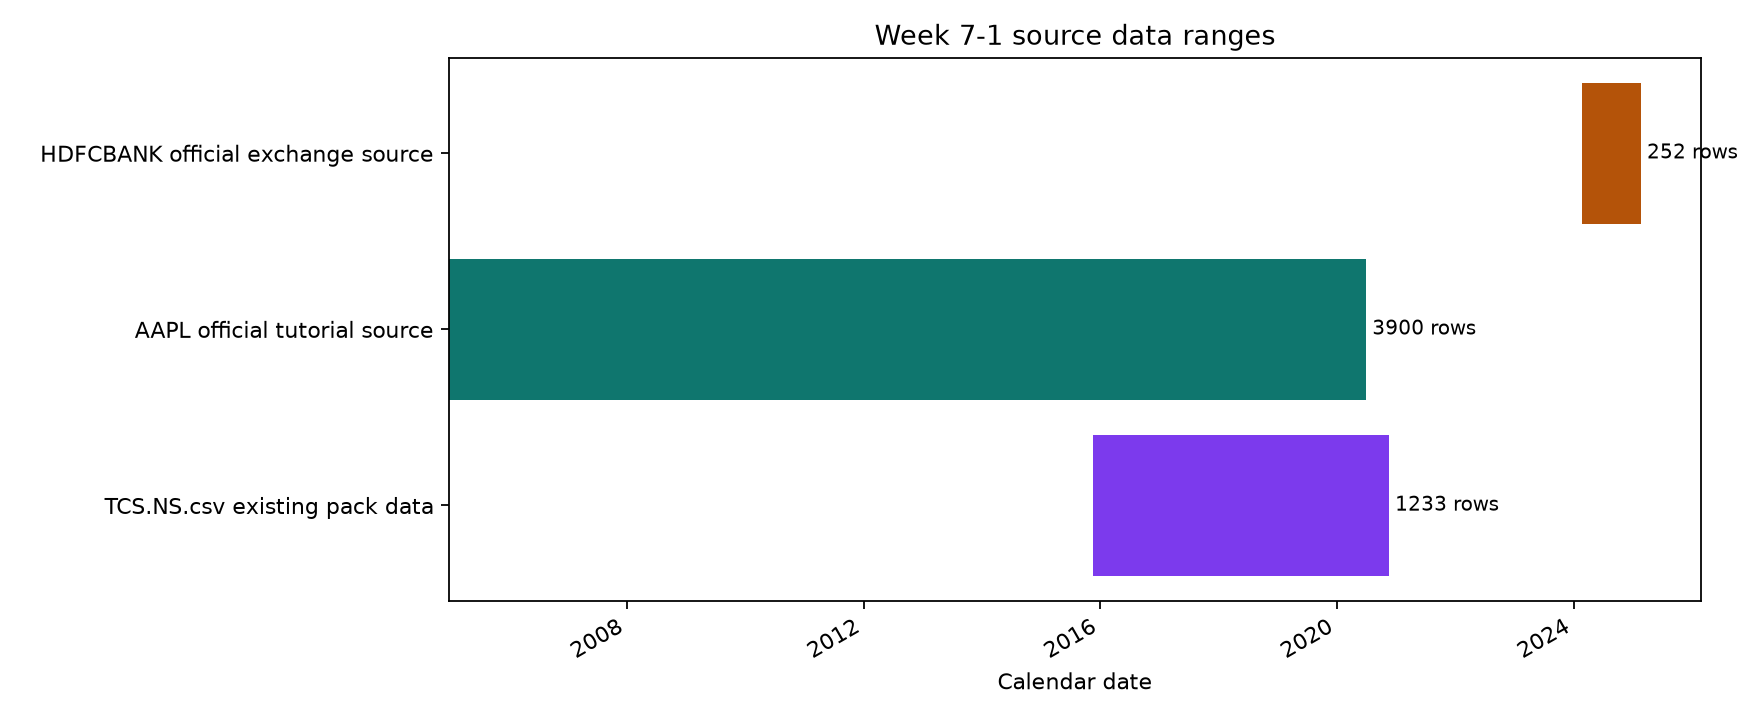

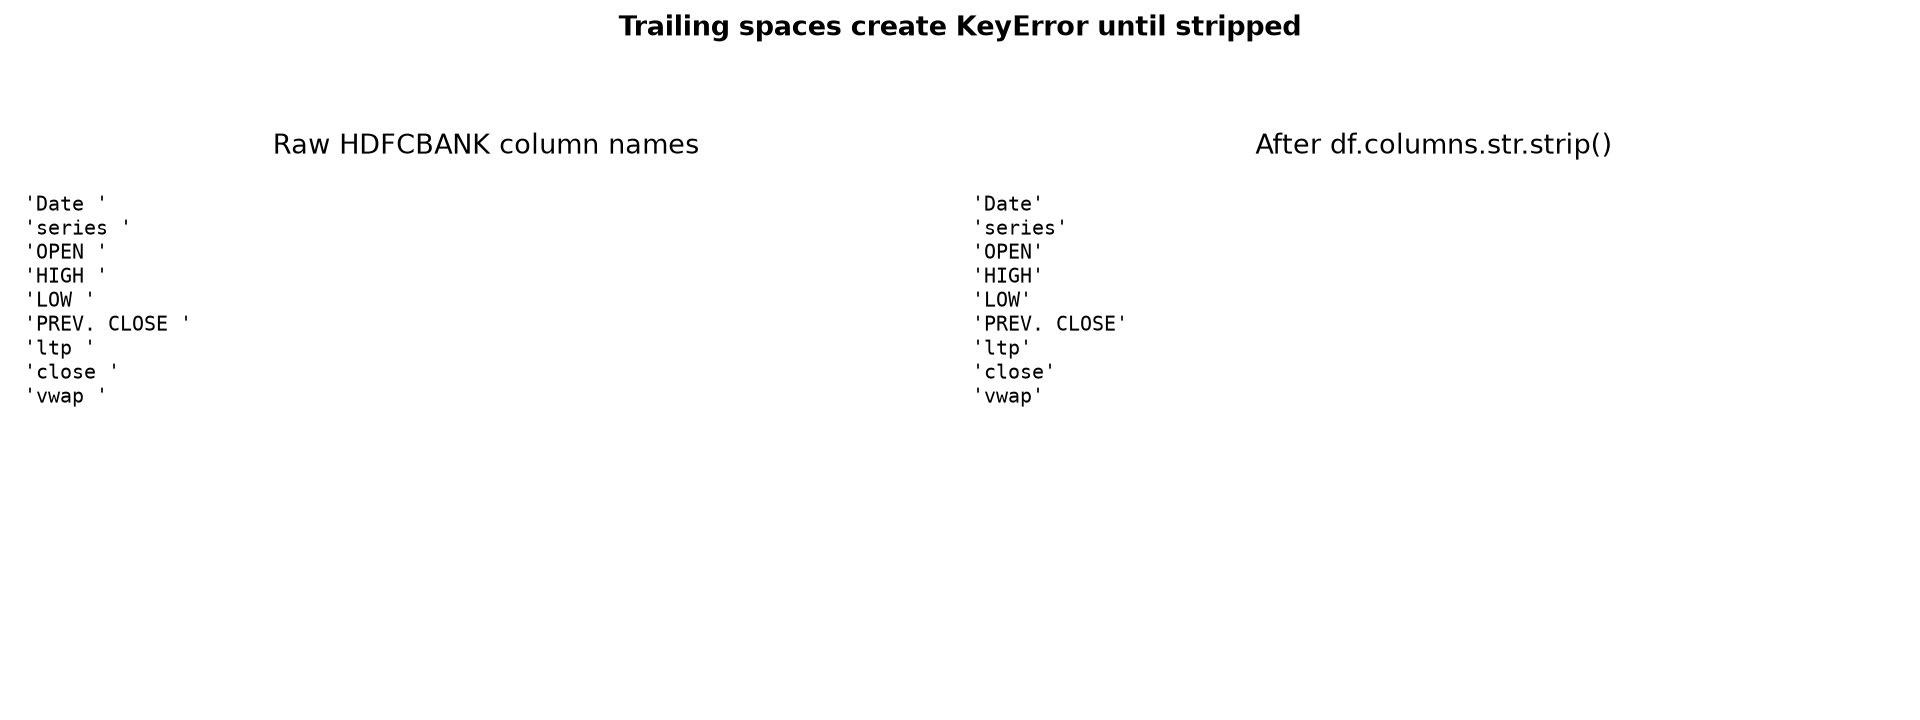

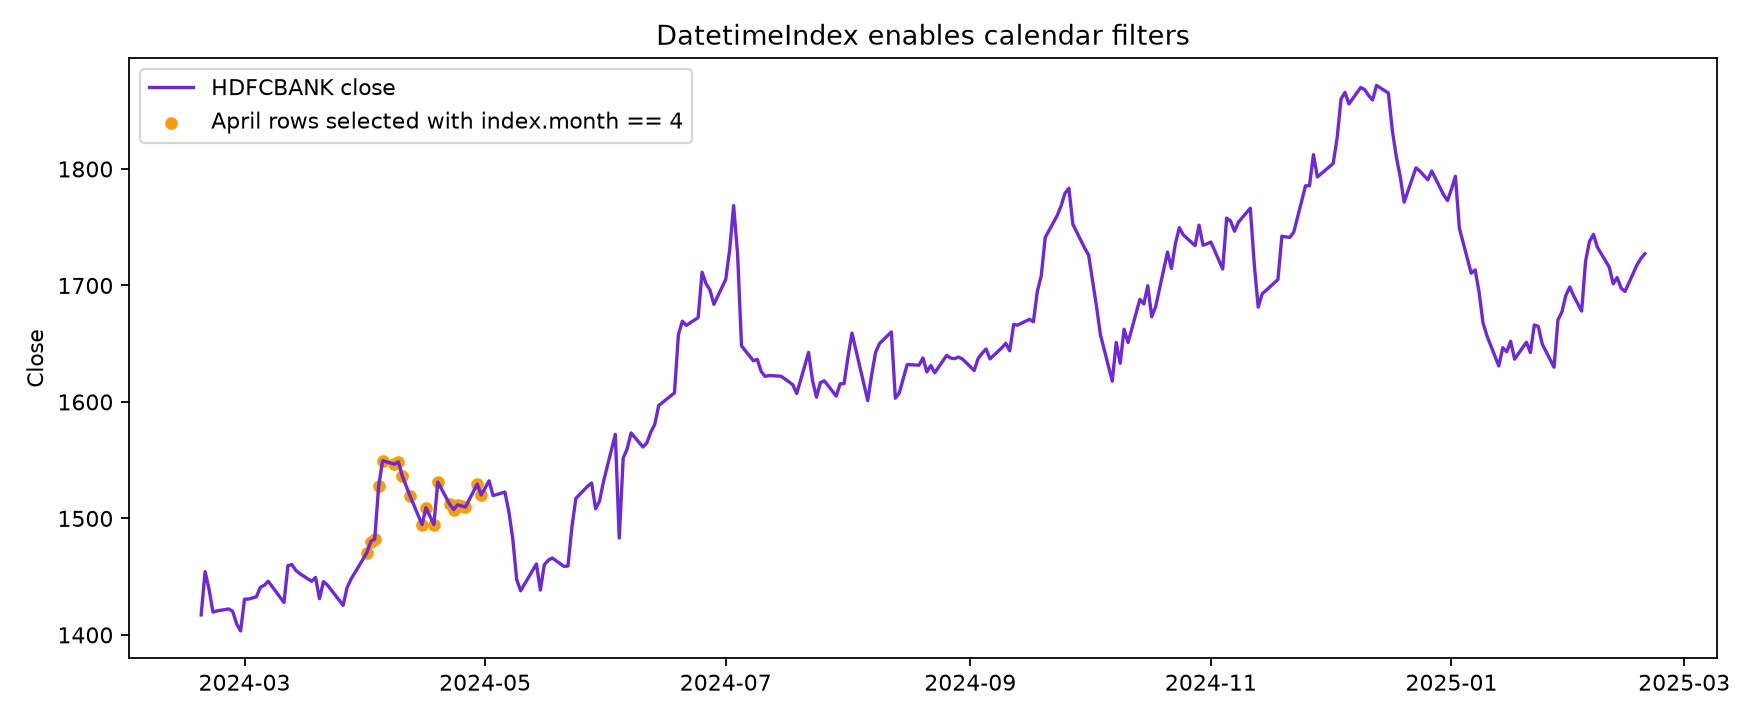

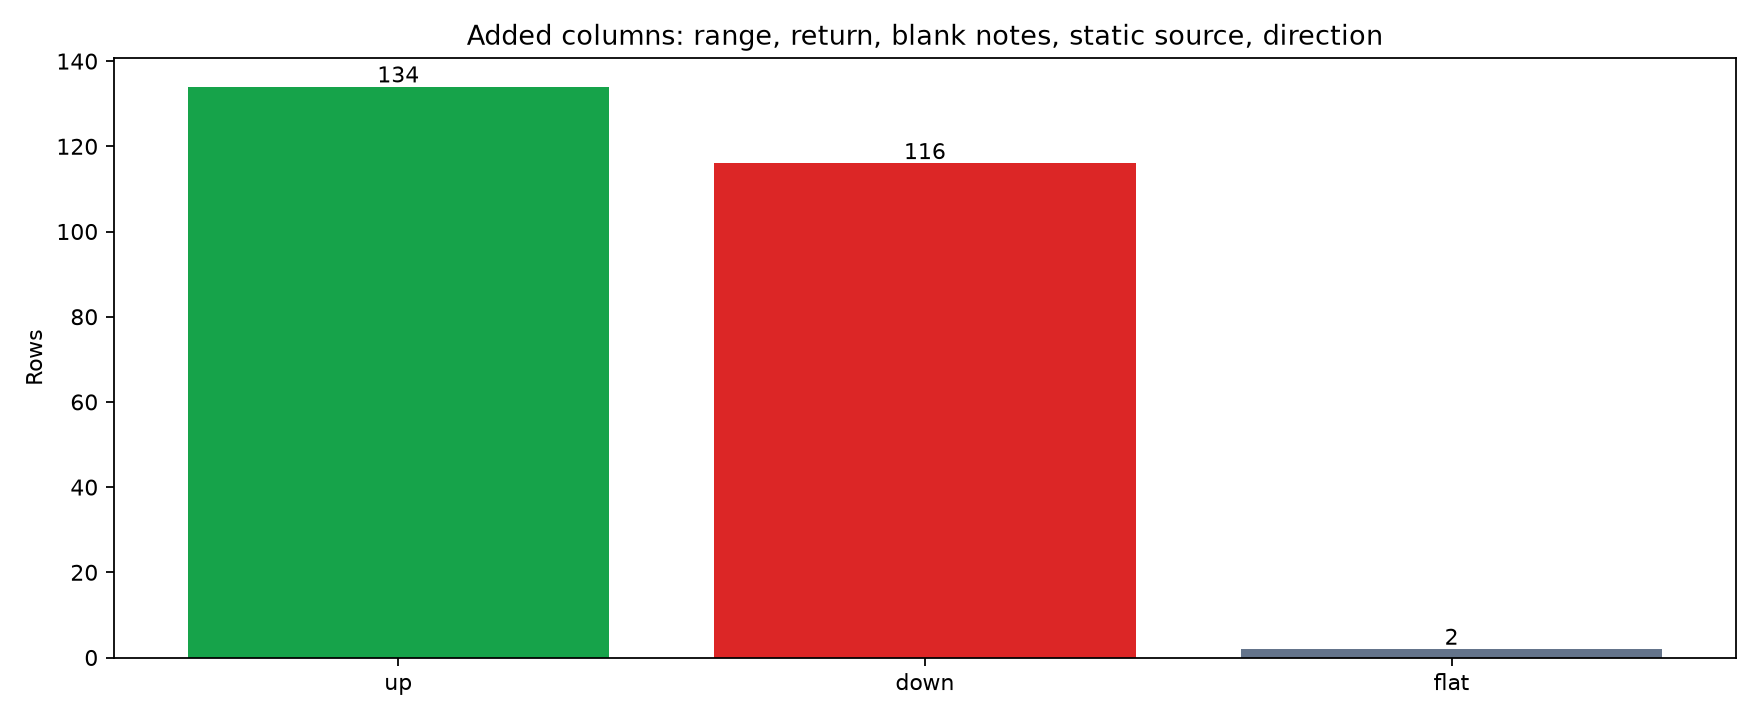

In [21]:
from IPython.display import Image, display
for image in [
    'chart_addendum_1_week7_source_data_ranges.png',
    'chart_addendum_2_week7_hdfc_column_cleanup.png',
    'chart_addendum_3_week7_calendar_slicing.png',
    'chart_addendum_4_week7_dataframe_modification.png',
]:
    display(Image(filename=image))

## 8. Learning and library notes

The transcript names quantstats, pyfolio, backtrader, and zipline as examples of quant/backtesting libraries. The practical rule is to understand the pandas workflow first, then use specialized libraries as tools.

In [22]:
display(pd.read_csv('week7_pandas_tutorial_reference.csv'))
print('Resource addendum complete')

,topic,transcript_rule,additive_example
0,documentation_search,"Know the objective first, then use documentati...",help(pd.set_option); dir(np); np.quantile?
1,warnings,Warnings are not errors; they can be hidden fo...,"warnings.filterwarnings(""ignore"")"
2,display_options,Use set_option for readable floats or more row...,"pd.set_option(""display.float_format"", lambda x..."
3,exchange_csv_cleanup,Hidden spaces in exchange column names cause K...,df.columns = df.columns.str.strip()
4,datetime_index,Read dates as dates and set them as the index ...,"pd.read_csv(file, index_col=0, parse_dates=True)"
5,chronological_sort,Financial data is time series; sort in chronol...,df = df.sort_index()
6,loc_vs_iloc,loc uses labels and includes date endpoints; i...,"df.loc[""2024-04""]; df.iloc[-5:, :]"
7,modify_dataframe,Add null/static/computed columns deliberately ...,"df[""Range""] = df[""HIGH""] - df[""LOW""]"
8,interactive_charts,Plotly/cufflinks can create interactive candle...,"go.Candlestick(open=..., high=..., low=..., cl..."
9,quant_libraries,"Quantstats, pyfolio, backtrader, and legacy zi...",Use libraries after the pandas basics are unde...


Resource addendum complete
